In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("../data/processed/master_machining_dataset.csv")
FIGURE_DIR = Path("../results/figures")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (453, 8)


,Sample_ID,Experiment_Path,Surface_Roughness_Ra,Depth_of_Cut_ap,Feed_Rate_f,Cutting_Speed_vc,Material,Tool
0,K0025,K0025/Scope_2025_05_08_13_52_02,1.203,0.5,0.125,125.0,20MnCr5,DNMG150608
1,K0025,K0025/Scope_2025_05_08_13_56_07,1.545,0.5,0.175,125.0,20MnCr5,DNMG150608
2,K0025,K0025/Scope_2025_05_08_13_59_14,2.389,0.5,0.225,125.0,20MnCr5,DNMG150608
3,K0025,K0025/Scope_2025_05_08_14_03_02,3.339,0.5,0.275,125.0,20MnCr5,DNMG150608
4,K0025,K0025/Scope_2025_05_08_14_06_26,0.888,0.5,0.125,175.0,20MnCr5,DNMG150608


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Sample_ID             453 non-null    str    
 1   Experiment_Path       453 non-null    str    
 2   Surface_Roughness_Ra  453 non-null    float64
 3   Depth_of_Cut_ap       453 non-null    float64
 4   Feed_Rate_f           453 non-null    float64
 5   Cutting_Speed_vc      453 non-null    float64
 6   Material              453 non-null    str    
 7   Tool                  453 non-null    str    
dtypes: float64(4), str(4)
memory usage: 28.4 KB


In [19]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
Sample_ID               0
Experiment_Path         0
Surface_Roughness_Ra    0
Depth_of_Cut_ap         0
Feed_Rate_f             0
Cutting_Speed_vc        0
Material                0
Tool                    0
dtype: int64

Duplicate rows:
0


In [20]:
print("Materials:")
print(df["Material"].value_counts())

print("\nTools:")
print(df["Tool"].value_counts())

print("\nUnique materials:", df["Material"].nunique())
print("Unique tools:", df["Tool"].nunique())

Materials:
Material
20MnCr5       151
EN AW-6082    151
41Cr4         151
Name: count, dtype: int64

Tools:
Tool
DNMG150608    453
Name: count, dtype: int64

Unique materials: 3
Unique tools: 1


In [21]:
numeric_features = [
    "Cutting_Speed_vc",
    "Feed_Rate_f",
    "Depth_of_Cut_ap",
    "Surface_Roughness_Ra"
]

df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Cutting_Speed_vc,453.0,197.671082,68.686604,100.000,150.000,200.000,250.000,300.000
Feed_Rate_f,453.0,0.197009,0.066818,0.100,0.150,0.200,0.250,0.300
Depth_of_Cut_ap,453.0,0.633664,0.205939,0.250,0.500,0.500,0.750,1.500
Surface_Roughness_Ra,453.0,1.865923,1.088385,0.288,0.949,1.744,2.725,3.944


,Cutting_Speed_vc,Feed_Rate_f,Depth_of_Cut_ap,Surface_Roughness_Ra
Cutting_Speed_vc,1.000000,0.001142,-0.018664,-0.064781
Feed_Rate_f,0.001142,1.000000,-0.040988,0.950529
Depth_of_Cut_ap,-0.018664,-0.040988,1.000000,-0.062358
Surface_Roughness_Ra,-0.064781,0.950529,-0.062358,1.000000


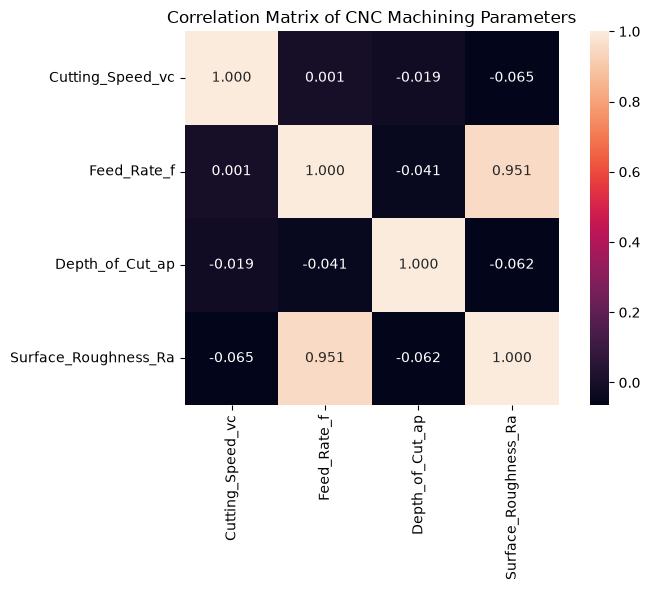

In [22]:
corr = df[numeric_features].corr()

display(corr)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    square=True
)

plt.title("Correlation Matrix of CNC Machining Parameters")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

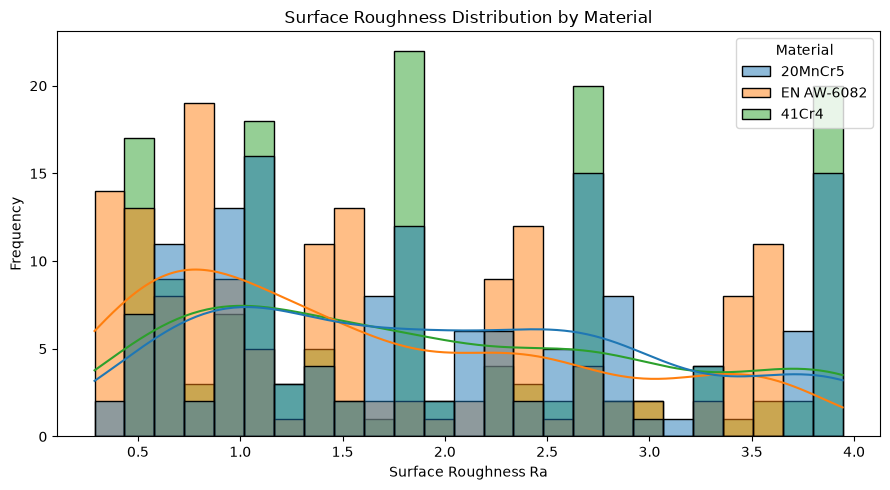

In [23]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Surface_Roughness_Ra",
    hue="Material",
    kde=True,
    bins=25
)

plt.title("Surface Roughness Distribution by Material")
plt.xlabel("Surface Roughness Ra")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "ra_distribution_by_material.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
material_stats = (
    df.groupby("Material")["Surface_Roughness_Ra"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .round(4)
)

material_stats

,count,mean,std,min,median,max
Material,,,,,,
20MnCr5,151,2.0025,1.0674,0.403,1.842,3.908
41Cr4,151,1.9758,1.1236,0.485,1.811,3.944
EN AW-6082,151,1.6195,1.0372,0.288,1.433,3.626


In [25]:
for material in df["Material"].unique():
    print("\n" + "=" * 60)
    print("Material:", material)
    print("=" * 60)

    subset = df[df["Material"] == material]

    display(
        subset[
            [
                "Cutting_Speed_vc",
                "Feed_Rate_f",
                "Depth_of_Cut_ap",
                "Surface_Roughness_Ra"
            ]
        ].corr().round(3)
    )


Material: 20MnCr5


,Cutting_Speed_vc,Feed_Rate_f,Depth_of_Cut_ap,Surface_Roughness_Ra
Cutting_Speed_vc,1.000,0.014,0.006,-0.142
Feed_Rate_f,0.014,1.000,-0.051,0.918
Depth_of_Cut_ap,0.006,-0.051,1.000,-0.128
Surface_Roughness_Ra,-0.142,0.918,-0.128,1.000



Material: EN AW-6082


,Cutting_Speed_vc,Feed_Rate_f,Depth_of_Cut_ap,Surface_Roughness_Ra
Cutting_Speed_vc,1.000,0.033,-0.046,0.001
Feed_Rate_f,0.033,1.000,-0.087,0.978
Depth_of_Cut_ap,-0.046,-0.087,1.000,-0.079
Surface_Roughness_Ra,0.001,0.978,-0.079,1.000



Material: 41Cr4


,Cutting_Speed_vc,Feed_Rate_f,Depth_of_Cut_ap,Surface_Roughness_Ra
Cutting_Speed_vc,1.000,-0.045,-0.016,-0.060
Feed_Rate_f,-0.045,1.000,0.016,0.990
Depth_of_Cut_ap,-0.016,0.016,1.000,0.016
Surface_Roughness_Ra,-0.060,0.990,0.016,1.000


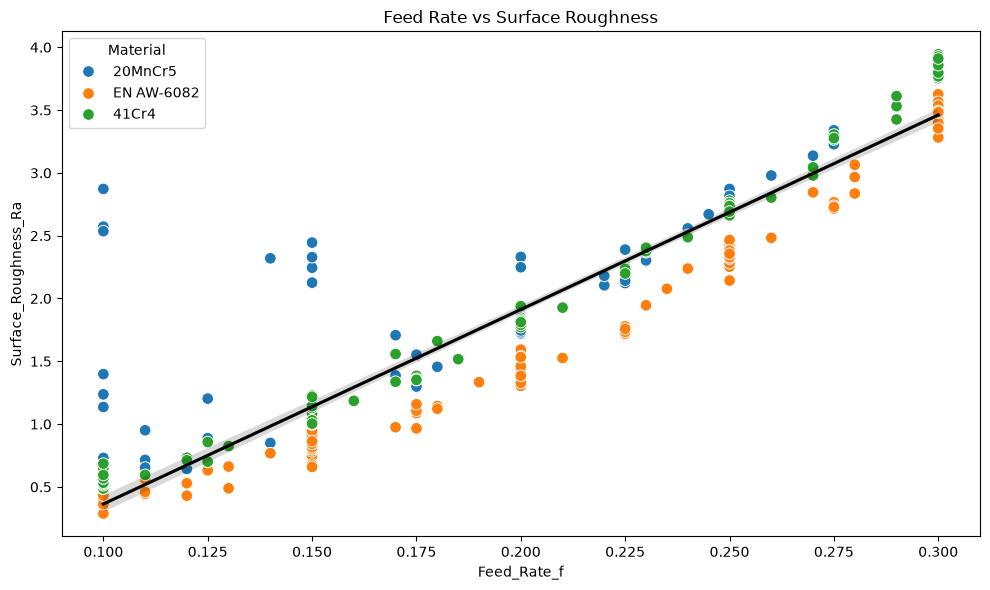

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Feed_Rate_f",
    y="Surface_Roughness_Ra",
    hue="Material",
    s=70
)

sns.regplot(
    data=df,
    x="Feed_Rate_f",
    y="Surface_Roughness_Ra",
    scatter=False,
    color="black"
)

plt.title("Feed Rate vs Surface Roughness")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "feed_rate_vs_surface_roughness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

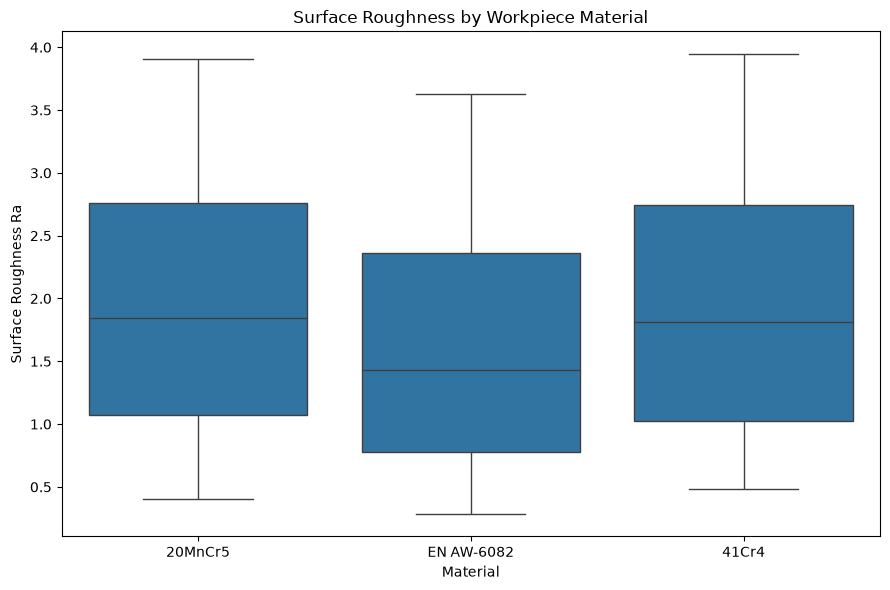

In [27]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Material",
    y="Surface_Roughness_Ra"
)

plt.title("Surface Roughness by Workpiece Material")
plt.xlabel("Material")
plt.ylabel("Surface Roughness Ra")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "surface_roughness_by_material.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
print("Unique Sample IDs:", df["Sample_ID"].nunique())

sample_counts = df["Sample_ID"].value_counts()

print("\nExperiments per Sample ID:")
print(sample_counts)

print("\nMinimum experiments per sample:", sample_counts.min())
print("Maximum experiments per sample:", sample_counts.max())

Unique Sample IDs: 3

Experiments per Sample ID:
Sample_ID
K0025    151
K0026    151
K0027    151
Name: count, dtype: int64

Minimum experiments per sample: 151
Maximum experiments per sample: 151
